In [548]:
import numpy as np

import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
from baselines import *

In [549]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=925) #abalone = 1, InfraRed = 925, concrete = 165, Auto MPG = 9, Automobile = 10
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets
  
print(f'Amount of features: {X.shape[1]}, amount of datapoints: {X.shape[0]}')

y = y[y.columns[0]]


Amount of features: 33, amount of datapoints: 1020


In [550]:
X

,Gender,Age,Ethnicity,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,...,T_FHCC1,T_FHRC1,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1
0,Male,41-50,White,24.0,28.0,0.8,0.7025,35.0300,35.3775,34.4000,...,33.5775,33.4775,33.3725,33.4925,33.0025,34.5300,34.0075,35.6925,35.6350,35.6525
1,Female,31-40,Black or African-American,24.0,26.0,0.8,0.7800,34.5500,34.5200,33.9300,...,34.0325,34.0550,33.6775,33.9700,34.0025,34.6825,34.6600,35.1750,35.0925,35.1075
2,Female,21-30,White,24.0,26.0,0.8,0.8625,35.6525,35.5175,34.2775,...,34.9000,34.8275,34.6475,34.8200,34.6700,35.3450,35.2225,35.9125,35.8600,35.8850
3,Female,21-30,Black or African-American,24.0,27.0,0.8,0.9300,35.2225,35.6125,34.3850,...,34.4400,34.4225,34.6550,34.3025,34.9175,35.6025,35.3150,35.7200,34.9650,34.9825
4,Male,18-20,White,24.0,27.0,0.8,0.8950,35.5450,35.6650,34.9100,...,35.0900,35.1600,34.3975,34.6700,33.8275,35.4175,35.3725,35.8950,35.5875,35.6175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,Female,21-25,Asian,25.7,50.8,0.6,1.2225,35.6425,35.6525,34.8575,...,35.1075,35.3475,35.4000,35.1375,35.2750,35.8525,35.7475,36.0675,35.6775,35.7100
1016,Female,21-25,White,25.7,50.8,0.6,1.4675,35.9825,35.7575,35.4275,...,35.3100,35.2175,35.2200,35.2075,35.0700,35.7650,35.5525,36.5000,36.4525,36.4900
1017,Female,18-20,Black or African-American,28.0,24.3,0.6,0.1300,36.4075,36.3400,35.8700,...,35.4350,35.2400,35.2275,35.3675,35.3425,36.3750,35.7100,36.5350,35.9650,35.9975
1018,Male,26-30,Hispanic/Latino,25.0,39.8,0.6,1.2450,35.8150,35.5250,34.2950,...,34.8400,35.0200,34.9250,34.7150,34.5950,35.4150,35.3100,35.8600,35.4150,35.4350


In [551]:
# Order DataFrame by this value
data = X.copy()
data['target'] = y #add this to the entire data, as we will order them
# Convert object columns to category first
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype('category')

# Now convert category columns to numeric codes
for col in data.select_dtypes(include='category').columns:
    data[col] = data[col].cat.codes



In [552]:
target_column = 'target'
predictor_columns = list(X.columns)

In [553]:
#Identify each correlation with target variable
single_features = []
features = []
corr_coefs = []
for feature in X.columns:
    single_feature = X[feature]
    single_features.append(single_feature)
    features.append(feature)
    if np.issubdtype(single_feature.dtype, np.number):
        corr_coef = np.abs(float(np.corrcoef(single_feature, y)[0,1]))
    else:
        corr_coef = 0
    corr_coefs.append(corr_coef)

# Select the variable that has correlation closest to 0.4
idx = min(range(len(corr_coefs)), key=lambda i: abs(corr_coefs[i] - 0.4))
closest_value = corr_coefs[idx]
selected_variable = X.columns[idx]

#sort by this value, and remove the column!
data = data.sort_values(by = selected_variable)
data = data.drop(columns = selected_variable)
predictor_columns.remove(selected_variable)

# Split data into three equally sized components
n = len(data)
t = n // 3  # size of each part

df1 = data.iloc[:t]
df2 = data.iloc[t:2*t]
df3 = data.iloc[2*t:]

#randomly select the target set
df = [df1, df2, df3]
random_index =  0 #np.random.choice(3)
data_target = df[random_index]
data_source = pd.concat([df[i] for i in range(3) if i != random_index], ignore_index=True)

print(f'splitting variable: {selected_variable}')
print(f'correlation of splitting variable with target: {closest_value}')



splitting variable: T_FHLC1
correlation of splitting variable with target: 0.3996491443726985


In [554]:
data_train, data_test = train_test_split(data_target, test_size=0.1, random_state=34)

X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

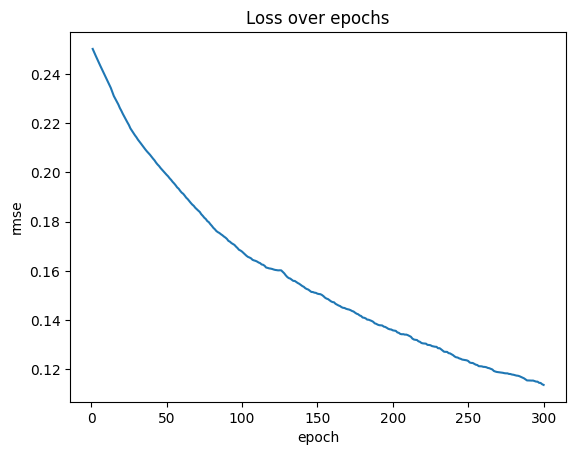

0.22211961351459877


In [555]:
fiter = MTransferTreeBoost(epochs=300, k = 0.01)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

print(rmse)

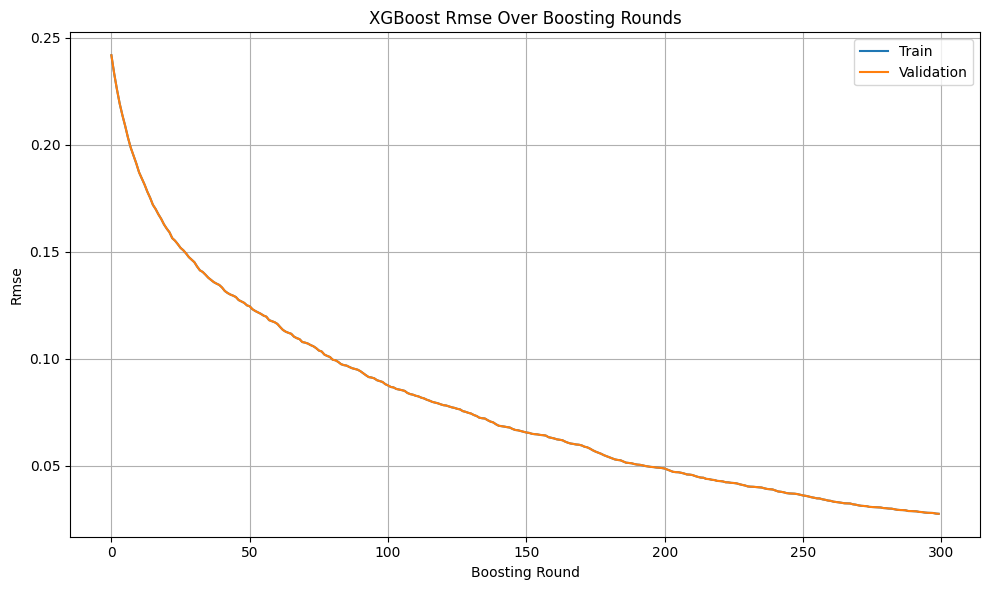

0.24430665778007385


In [556]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 3,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_train, y_target_train, boosting_rounds=300, params=params, early_stopping_rounds=500, show_curve=True)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print(rmse)